# Big Five EXT_score Classification: Model Comparison & Visualization
This notebook compares multiple classifiers (Logistic Regression, SVM, KNN, Random Forest) for predicting EXT_score (high vs low) and generates/saves all relevant images.

In [1]:
# Install required packages
%pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load and prepare data
import pandas as pd
import numpy as np
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
df = pd.read_csv('data-final.csv', sep='\t', low_memory=False, nrows=10000)
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
question_cols = [f'{trait}{i}' for trait in trait_prefixes for i in range(1,11)]
score_cols = [f'{trait}_score' for trait in trait_prefixes]
df_clean = df[question_cols + score_cols].dropna(subset=score_cols)

C:\Users\INSPIRON\AppData\Local\Temp\ipykernel_15928\3166000441.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# Binarize EXT_score for classification
df_clean['EXT_high'] = (df_clean['EXT_score'] > 3).astype(int)

In [4]:
# Train/test split
from sklearn.model_selection import train_test_split
X = df_clean[question_cols]
y = df_clean['EXT_high']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

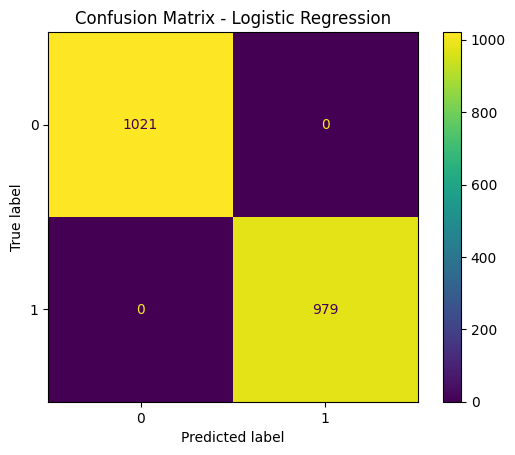

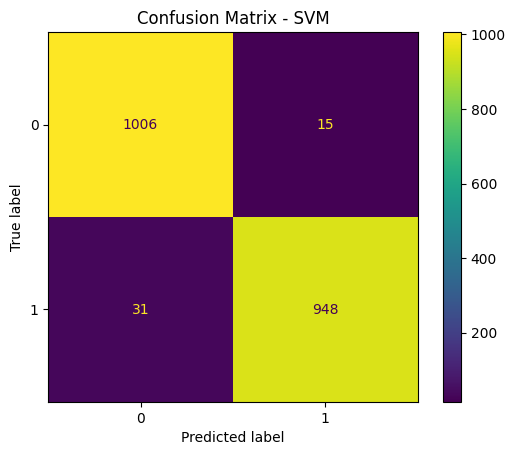

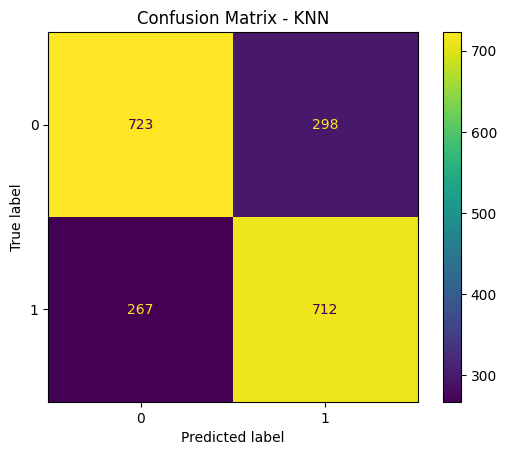

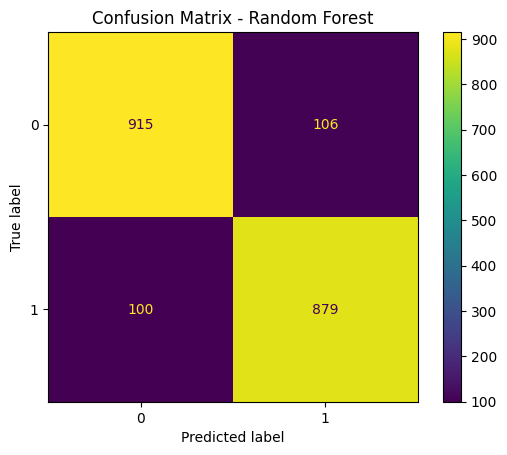

In [5]:
# Train and evaluate classifiers, generate confusion matrices
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_").lower()}.png')
    plt.show()

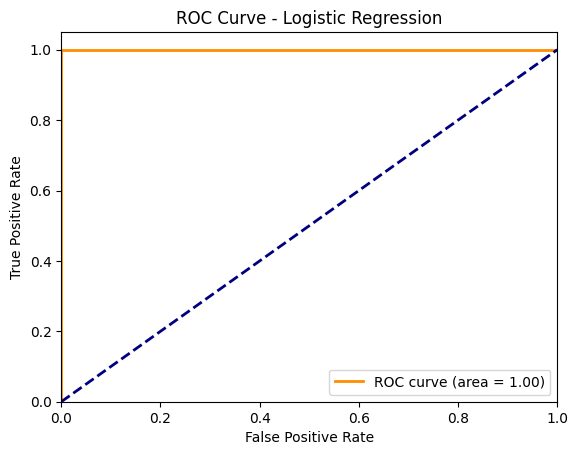

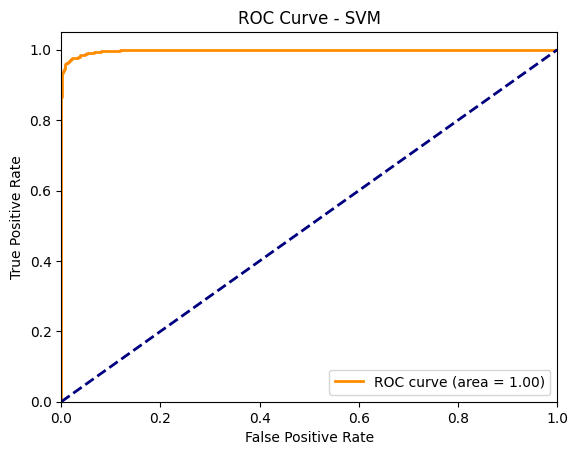

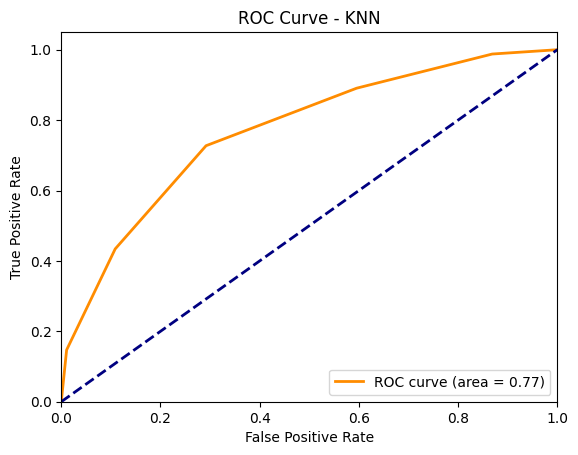

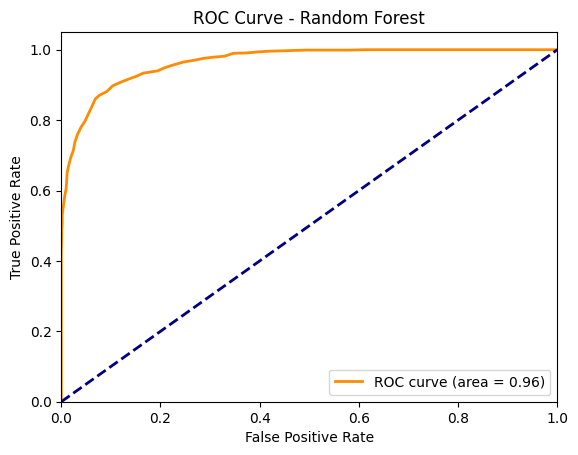

In [6]:
# Generate and save ROC curves for all models
from sklearn.metrics import roc_curve, auc
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc="lower right")
    plt.savefig(f'roc_curve_{name.replace(" ", "_").lower()}.png')
    plt.show()

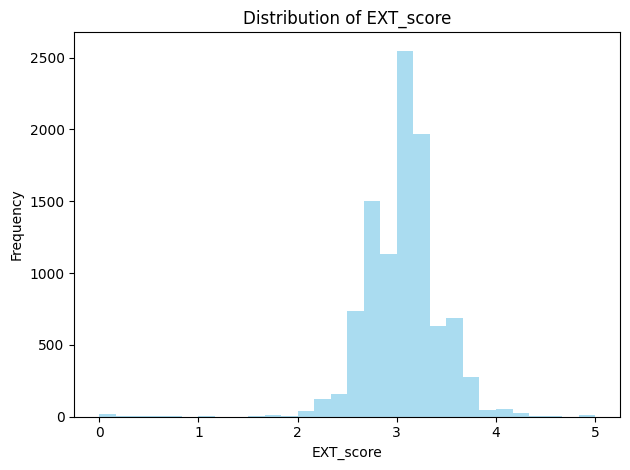

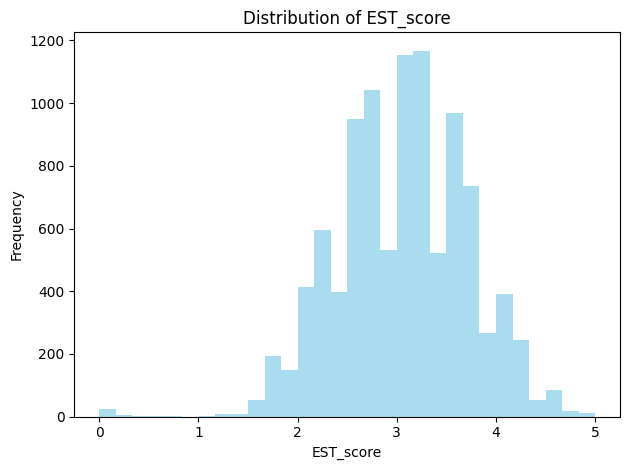

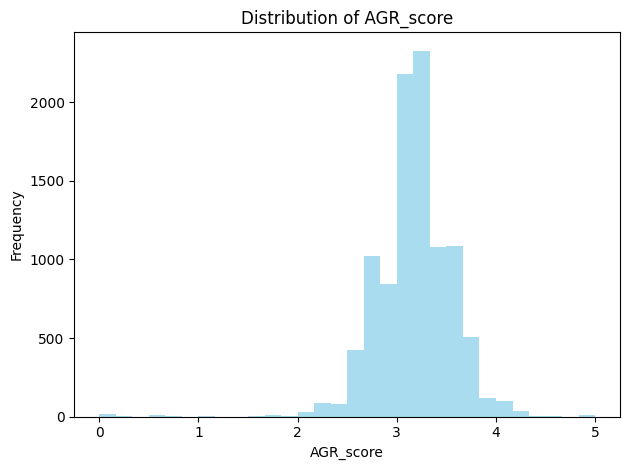

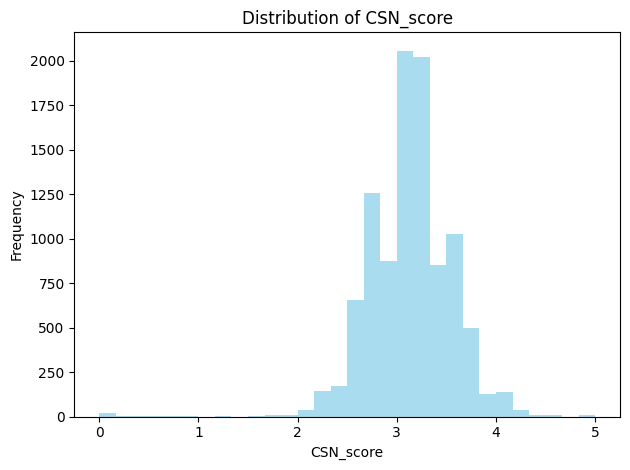

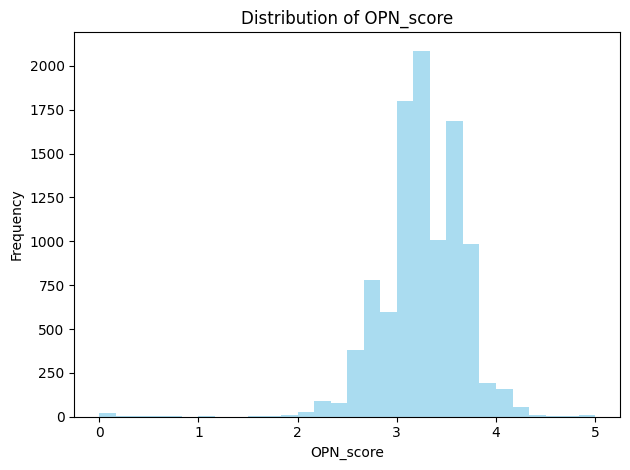

In [7]:
# Plot and save trait score distributions
for trait in trait_prefixes:
    plt.figure()
    plt.hist(df_clean[f'{trait}_score'], bins=30, alpha=0.7, color='skyblue')
    plt.title(f'Distribution of {trait}_score')
    plt.xlabel(f'{trait}_score')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'distribution_{trait}.png')
    plt.show()

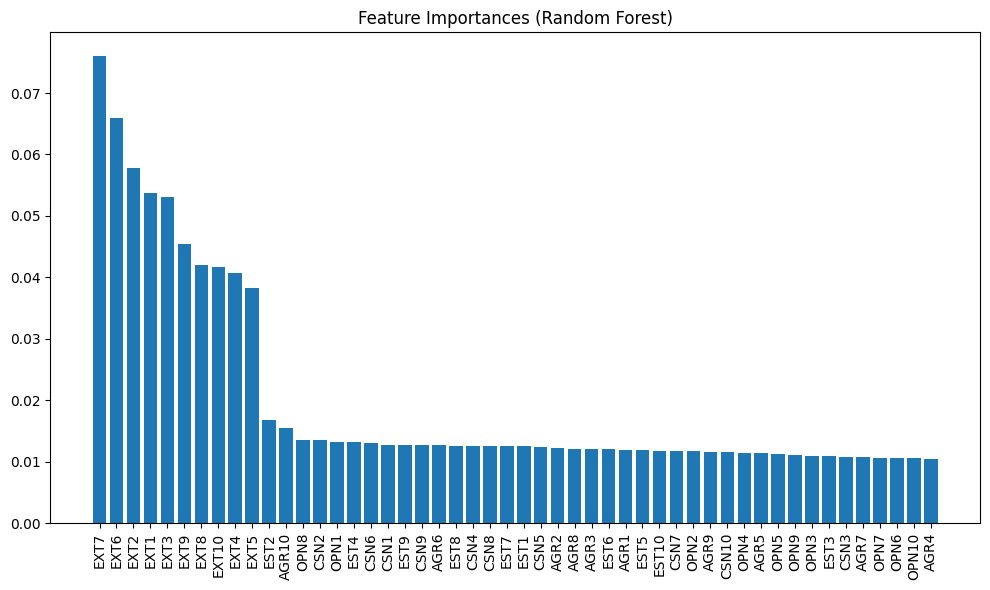

In [8]:
# Plot and save feature importances for Random Forest
rf = models['Random Forest']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_test.columns
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()